### Figures for "Translating neutron star observations to nuclear symmetry energy via artificial neural networks" — new data set
The figures of the paper (made there by `figures.ipynb`, not included here), made from the new data (`eos_paper_v1–v4.h5`, `ns_paper_v1–v4.h5`) and the DNNs trained by `train_esym_dnn.py` (`models/`). The figures are written to `figures/`, with the same file names as in the paper's notebook.

Differences with respect to the paper's notebook: the M–R and M–Λ inputs and the predictions are the test-set samples the models were evaluated on (saved with the models, seeded), and the curves are drawn on the stable branch (up to the maximum mass).

In [1]:
import os
import json
import h5py
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')
os.environ.setdefault('TF_FORCE_GPU_ALLOW_GROWTH', 'true')

import esym_data as ed
from esym_data import e_0, e_sym

# --- (i) physical / mathematical constants ---
rho0  = ed.rho0                # density of normal nuclear matter
c     = ed.c                   # Speed of light (cgs)
g     = ed.g                   # Gravitational constant (cgs)
m_sun = ed.m_sun               # Mass of the Sun (cgs)

# --- (ii) conversion factors ---
fm3cm3      = ed.fm3cm3
mevfm3gcm3  = ed.mevfm3gcm3
dycm2mevfm3 = ed.dycm2mevfm3

MODEL_DIR = 'models'
FIG_DIR   = 'figures'
DPI       = 1000
os.makedirs(FIG_DIR, exist_ok=True)
savefig = lambda name: plt.savefig(os.path.join(FIG_DIR, name), format='png', dpi=DPI, bbox_inches='tight')

#### Energy of symmetric matter and symmetry energy

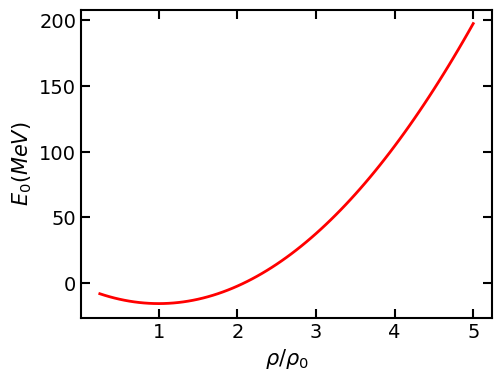

In [2]:
ed.rc_params()
rho = np.arange(0.04,0.81,0.01)
e0 = e_0(rho)

fig, ax = plt.subplots(figsize=(5.3,4.0))
plt.plot(rho/rho0, e0, color='red', linewidth=2)
plt.ylabel(r'$E_{0} (MeV)$', size=15)
plt.xlabel(r'$\rho/\rho_0$', size=15)
savefig('e0.png')
plt.show()

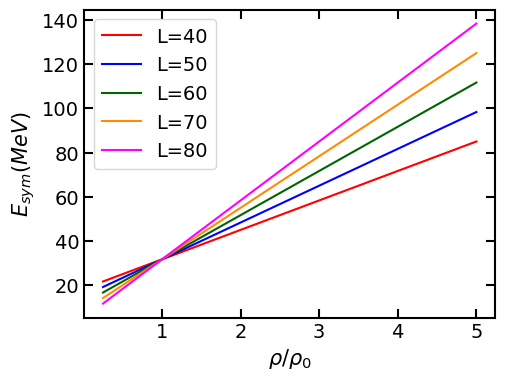

In [3]:
fig, ax = plt.subplots(figsize=(5.3,4.0))
plt.plot(rho/rho0, e_sym(rho,40), color='red', linestyle='-', label='L=40')
plt.plot(rho/rho0, e_sym(rho,50), color='blue', linestyle='-', label='L=50')
plt.plot(rho/rho0, e_sym(rho,60), color='darkgreen', linestyle='-', label='L=60')
plt.plot(rho/rho0, e_sym(rho,70), color='darkorange', linestyle='-', label='L=70')
plt.plot(rho/rho0, e_sym(rho,80), color='magenta', linestyle='-', label='L=80')
plt.xlabel(r'$\rho/\rho_0$', size=15)
plt.ylabel(r'$E_{sym} (MeV)$', size=15)
plt.legend(fontsize=14, loc="upper left", frameon=True)
savefig('e_sym_L.png')
plt.show()

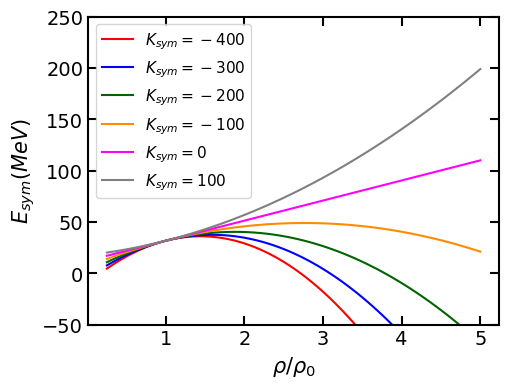

In [4]:
fig, ax = plt.subplots(figsize=(5.3,4.0))
plt.plot(rho/rho0, e_sym(rho, 58.7, -400.0), color='red', label='$K_{sym}=-400$')
plt.plot(rho/rho0, e_sym(rho, 58.7, -300.0), color='blue', label='$K_{sym}=-300$')
plt.plot(rho/rho0, e_sym(rho, 58.7, -200.0), color='darkgreen', label='$K_{sym}=-200$')
plt.plot(rho/rho0, e_sym(rho, 58.7, -100.0), color='darkorange', label='$K_{sym}=-100$')
plt.plot(rho/rho0, e_sym(rho, 58.7, 0.0), color='magenta', label='$K_{sym}=0$')
plt.plot(rho/rho0, e_sym(rho, 58.7, 100.0), color='grey', label='$K_{sym}=100$')
plt.xlabel(r'$\rho/\rho_0$', size=15)
plt.ylabel(r'$E_{sym} (MeV)$', size=15)
plt.ylim(-50, 250)
plt.legend(fontsize=11.0, loc="upper left", frameon=True)
savefig('e_sym_Ksym.png')
plt.show()

#### Ranges of the EOS and of the neutron-star properties

In [5]:
def rc_params():
    """Set rcParams for this plot (second style of figures.ipynb)"""
    params = {
        'axes.linewidth':1.5,
        'xtick.major.size':6.5,
        'xtick.major.width':1.5,
        'xtick.minor.size':3.5,
        'xtick.minor.width':1.5,
        'ytick.major.size':6.5,
        'ytick.major.width':1.5,
        'ytick.minor.size':3.5,
        'ytick.minor.width':1.5,
        'xtick.labelsize':14,
        'ytick.labelsize':14,
        'xtick.direction':'out',
        'ytick.direction':'out',
        'xtick.top':False,
        'ytick.right':False
        }
    mpl.rcParams.update(params)

rc_params()

# --- first 3000 EOSs (all, before the NS quality filter), as in figures.ipynb ---
with h5py.File(ed.EOS_FILES[0], 'r') as f:
    eos_arr  = f['eos'][:3000]
    esym_arr = f['eospar'][:3000]     # [L, Ksym]

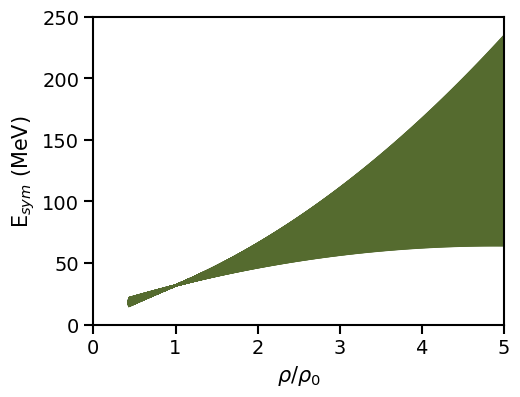

In [6]:
rhox = ed.RHOX
fig, ax = plt.subplots(figsize=(5.3,4.0))
for i in range(3000):
    L    = esym_arr[i,0]
    Ksym = esym_arr[i,1]
    esym = e_sym(rhox, L, Ksym)
    plt.plot(rhox/rho0, esym, color='darkolivegreen')
plt.xlim(0,5)
plt.ylim(0,250)
plt.xlabel(r'$\rho/\rho_0$', size=15)
plt.ylabel(r'E$_{sym}$ (MeV)', size=15)
savefig('e_sym_range.png')
plt.show()

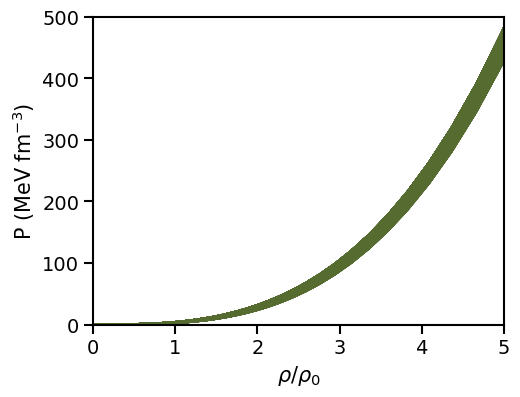

In [7]:
fig, ax = plt.subplots(figsize=(5.3,4.0))
for i in range(3000):
    py = eos_arr[i,1,:]*dycm2mevfm3
    rhoy = eos_arr[i,2,:]/fm3cm3
    plt.plot(rhoy/0.16, py, color='darkolivegreen')
plt.xlim(0,5)
plt.ylim(0,500)
plt.xlabel(r'$\rho/\rho_0$', size=15)
plt.ylabel(r'P (MeV fm$^{-3}$)', size=15)
savefig('p_range.png')
plt.show()

In [8]:
data = ed.load_dataset(ed.NS_FILES)
m_arr, r_arr, Lambda_arr = data['m'], data['r'], data['Lambda']
N = len(m_arr)
print('%d sequences, %d pass the quality filter' % (data['n_total'], N))

mz = np.linspace(0.5, 3.0, 100)
rz = 2.94 * (g*mz*m_sun/c**2)/1e5

60144 sequences, 49357 pass the quality filter


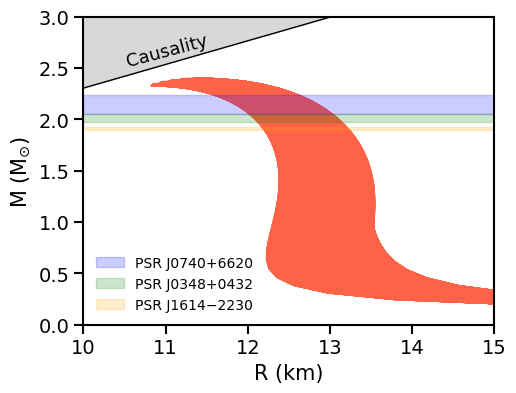

In [9]:
fig, ax = plt.subplots(figsize=(5.3,4.0))

for i in range(30000):
    ind_max = np.argmax(m_arr[i])
    plt.plot(r_arr[i,0:ind_max+1], m_arr[i,0:ind_max+1], color='tomato', linewidth=1, zorder=0)

plt.fill_between(rz, mz, y2 = 3.0, color='grey', alpha=0.3)
plt.plot(rz, mz, color='black', linewidth=1)
plt.fill_between([10, 15], y1 = 2.05, y2 = 2.24, color='blue', alpha=0.2, label='PSR J0740+6620')
plt.fill_between([10, 15], y1 = 1.97, y2 = 2.05, color='green', alpha=0.2, label='PSR J0348+0432')
plt.fill_between([10, 15], y1 = 1.892, y2 = 1.924, color='orange', alpha=0.2, label='PSR J1614−2230')
plt.xlim(10,15)
plt.ylim(0,3.0)

plt.xlabel(r'R (km)', size=15)
plt.ylabel(r'M (M$_{\odot}$)', size=15)
plt.text(10.5, 2.52, 'Causality', fontsize=13, color='black', rotation=15)
plt.legend(loc='lower left', fontsize=10, frameon=False)
savefig('m_range.png')
plt.show()

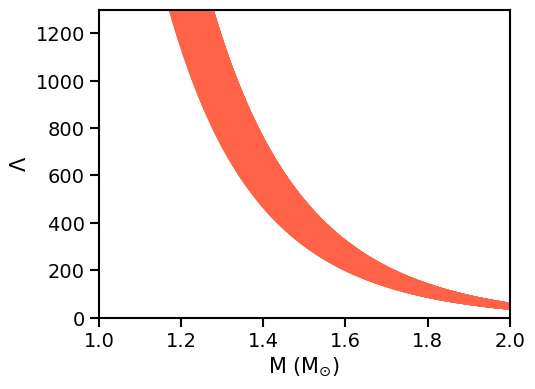

In [10]:
mxx = np.linspace(1.0, 2.0, 1000)

fig, ax = plt.subplots(figsize=(5.3,4.0))
for i in range(2000):
    ms, Ls = ed.stable_branch(m_arr[i], Lambda_arr[i])
    f = interp1d(ms, Ls, kind = 'cubic')
    plt.plot(mxx, f(mxx), color='tomato', linewidth=1)
plt.xlim(1, 2.0)
plt.ylim(0, 1300)
plt.ylabel(r'$\Lambda$', size=15)
plt.xlabel(r'M (M$_{\odot}$)', size=15)
savefig('lambda_range.png')
plt.show()

#### DNN with M–R input

In [11]:
from tensorflow import keras

def load_test(kind):
    """Saved test set and the predictions of the saved model"""
    t = dict(np.load(os.path.join(MODEL_DIR, 'esym_%s_test.npz' % kind)))
    model = keras.models.load_model(os.path.join(MODEL_DIR, 'esym_%s.keras' % kind))
    t['pred'] = model.predict(t['x_test'].astype('float32'), batch_size=500, verbose=0)
    return model, t

model_mr, test_mr = load_test('MR')
test_dim = len(test_mr['idx_test'])
print('test samples:', test_dim)
model_mr.summary()

2026-09-30 14:06:07.256904: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-30 14:06:07.270813: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-30 14:06:07.274743: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


test samples: 4679


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 100)            │        10,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 484,802 (1.85 MB)

 Trainable params: 121,200 (473.44 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 363,602 (1.39 MB)

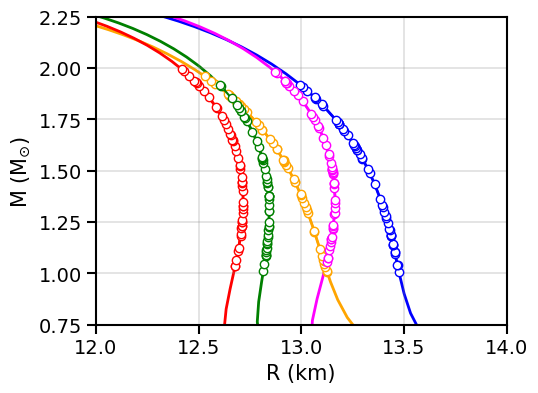

In [12]:
# 100, 10, 20, 583, 797
colors = {10: 'orange', 20: 'green', 100: 'blue', 583: 'red', 797: 'magenta'}
fig, ax = plt.subplots(figsize=(5.3,4.0))
for i, cc in colors.items():
    k = test_mr['idx_test'][i]
    ind_max = np.argmax(m_arr[k])
    mx = test_mr['x_test_raw'][i, :50]
    rx = test_mr['x_test_raw'][i, 50:]
    plt.plot(r_arr[k,0:ind_max+1], m_arr[k,0:ind_max+1], color=cc, linewidth=2, zorder=0)
    plt.plot(rx, mx, color=cc, marker='o', markerfacecolor="white", markeredgewidth=1, markeredgecolor=cc)
plt.xlim(12,14)
plt.ylim(0.75,2.25)

plt.xlabel(r'R (km)', size=15)
plt.ylabel(r'M (M$_{\odot}$)', size=15)
ax.grid(which='major', linestyle='-', linewidth='0.3', color='grey')
ax.grid(which='minor', linestyle='-', linewidth='0.3', color='grey')
savefig('M-R_input.png')
plt.show()

In [13]:
err_mr = np.abs(test_mr['y_test'] - test_mr['pred'])
ind = 99
print('mean abs err = ', np.mean(err_mr[:, ind]))
print('std = ', np.std(err_mr[:, ind]))

mean abs err =  0.1805604915650404
std =  0.15856127144425228


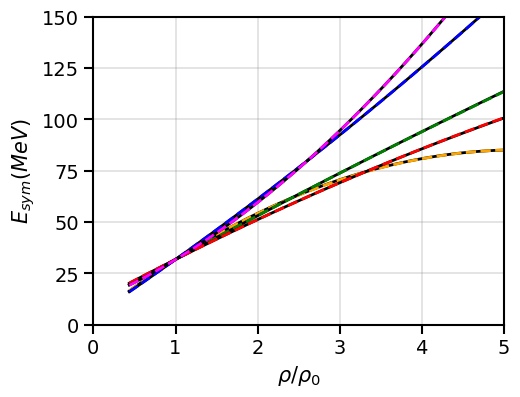

In [14]:
fig, ax = plt.subplots(figsize=(5.3,4.0))
y_test, predictions = test_mr['y_test'], test_mr['pred']
for i, cc in [(10, 'orange'), (20, 'green'), (100, 'blue'), (583, 'red'), (797, 'magenta')]:
    plt.plot(rhox/rho0, y_test[i,:], color='black', linewidth=2)
    plt.plot(rhox/rho0, predictions[i,:], '--', color=cc, linewidth=2)
plt.ylim(0, 150)
plt.xlim(0, 5)
plt.xlabel(r'$\rho/\rho_0$', size=15)
plt.ylabel(r'$E_{sym} (MeV)$', size=15)
ax.grid(which='major', linestyle='-', linewidth='0.3', color='grey')
ax.grid(which='minor', linestyle='-', linewidth='0.3', color='grey')
savefig('esym_out1.png')
plt.show()

#### DNN with M–Λ input

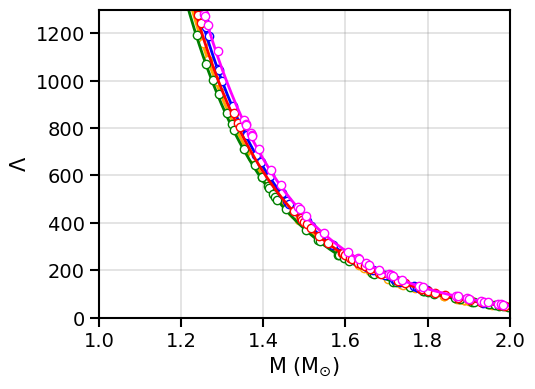

In [15]:
model_ml, test_ml = load_test('MLambda')

# 30, 114, 236, 681, 722
fig, ax = plt.subplots(figsize=(5.3,4.0))
for i, cc in [(30, 'orange'), (114, 'green'), (236, 'blue'), (681, 'red'), (722, 'magenta')]:
    k = test_ml['idx_test'][i]
    ms, Ls = ed.stable_branch(m_arr[k], Lambda_arr[k])
    f = interp1d(ms, Ls, kind = 'cubic')
    mx = test_ml['x_test_raw'][i, :50]
    Lx = test_ml['x_test_raw'][i, 50:]
    plt.plot(mxx, f(mxx), color=cc, linewidth=2)
    plt.plot(mx, Lx, color=cc, marker='o', markerfacecolor="white", markeredgewidth=1, markeredgecolor=cc,
            linestyle='')
plt.xlim(1, 2.0)
plt.ylim(0, 1300)
plt.ylabel(r'$\Lambda$', size=15)
plt.xlabel(r'M (M$_{\odot}$)', size=15)
ax.grid(which='major', linestyle='-', linewidth='0.3', color='grey')
ax.grid(which='minor', linestyle='-', linewidth='0.3', color='grey')
savefig('M-Lambda_input.png')
plt.show()

In [16]:
err_ml = np.abs(test_ml['y_test'] - test_ml['pred'])
print('mean abs err = ', np.mean(err_ml[:, ind]))
print('std = ', np.std(err_ml[:, ind]))

mean abs err =  0.4728037069946257
std =  0.4403404630638659


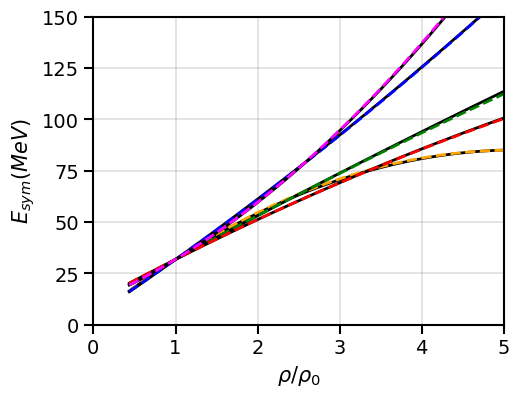

In [17]:
fig, ax = plt.subplots(figsize=(5.3,4.0))
y_test, predictions = test_ml['y_test'], test_ml['pred']
for i, cc in [(10, 'orange'), (20, 'green'), (100, 'blue'), (583, 'red'), (797, 'magenta')]:
    plt.plot(rhox/rho0, y_test[i,:], color='black', linewidth=2)
    plt.plot(rhox/rho0, predictions[i,:], '--', color=cc, linewidth=2)
plt.ylim(0, 150)
plt.xlim(0, 5)
plt.xlabel(r'$\rho/\rho_0$', size=15)
plt.ylabel(r'$E_{sym} (MeV)$', size=15)
ax.grid(which='major', linestyle='-', linewidth='0.3', color='grey')
ax.grid(which='minor', linestyle='-', linewidth='0.3', color='grey')
savefig('esym_out2.png')
plt.show()